In [1]:
# Initialization

from scipy.stats import loguniform
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from dotenv import load_dotenv
import comet_ml.integration.sklearn
import comet_ml
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import sys
import os

project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
if project_root not in sys.path:
    sys.path.append(project_root)

from src.logreg import MinibatchSGDWrapper
load_dotenv()

api_key = os.getenv("COMET_API_KEY")
comet_ml.login(api_key=api_key)
exp = comet_ml.start(project_name="logreg-hyperparam-tuning")
exp.set_name("LogReg Hyperparam Tuning")
exp.add_tag("logreg")

df = pd.read_csv("../data/data_processed.csv")

df.info()
df.head()

COMET INFO: Valid Comet API Key saved in C:\Users\Rohann\.comet.config (set COMET_CONFIG to change where it is saved).
COMET WARNING: To get all data logged automatically, import comet_ml before the following modules: sklearn.
COMET WARNING: As you are running in a Jupyter environment, you will need to call `experiment.end()` when finished to ensure all metrics and code are logged before exiting.
COMET INFO: Experiment is live on comet.com https://www.comet.com/solenad/logreg-hyperparam-tuning/689b181326694b5d9e46ef99ad7342de



<class 'pandas.DataFrame'>
RangeIndex: 76692 entries, 0 to 76691
Data columns (total 17 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   btb_mean                76692 non-null  float64
 1   btb_max                 76692 non-null  int64  
 2   combo_mean              76692 non-null  float64
 3   combo_max               76692 non-null  int64  
 4   immediate_garbage_mean  76692 non-null  float64
 5   immediate_garbage_max   76692 non-null  int64  
 6   incoming_garbage_mean   76692 non-null  float64
 7   incoming_garbage_max    76692 non-null  int64  
 8   won                     76692 non-null  int64  
 9   rating                  76692 non-null  float64
 10  glicko                  76692 non-null  float64
 11  glicko_rd               76692 non-null  float64
 12  duration_sec            76692 non-null  float64
 13  pps                     76692 non-null  float64
 14  attack_per_piece        76692 non-null  float64
 

,btb_mean,btb_max,combo_mean,combo_max,immediate_garbage_mean,immediate_garbage_max,incoming_garbage_mean,incoming_garbage_max,won,rating,glicko,glicko_rd,duration_sec,pps,attack_per_piece,apm,tspin_rate
0,1.933673,8,0.520408,7,0.244898,8,0.576531,15,1,24748.521,2701.8877,62.212624,70.600000,2.776204,0.821429,136.827195,0.076531
1,0.413953,4,0.590698,6,0.683721,13,1.432558,13,0,24820.710,2791.8670,63.886936,71.310000,3.015005,0.586047,106.015987,0.055814
2,0.611842,3,0.605263,8,0.250000,6,0.605263,6,1,24820.710,2791.8670,63.886936,49.275000,3.084729,0.671053,124.200913,0.065789
3,0.786765,4,0.588235,6,0.551471,9,1.227941,10,0,24748.521,2701.8877,62.212624,49.283333,2.759554,0.625000,103.483260,0.036765
4,1.277487,7,0.539267,5,0.366492,11,0.691099,11,1,24748.521,2701.8877,62.212624,69.525000,2.747213,0.670157,110.463862,0.057592


In [2]:
# Target separation
X = df.drop(columns=["won"])  # Features
y = df["won"]  # Target variable

In [3]:
# Split data into training and validation
# 85% / 15% split
# RandomizedSearchCV will automatically do a 15% split for validation
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.15, stratify=y, random_state=42
)

# Check sizes of splits
print(f"Training data: {X_train.shape}")
print(f"Training labels: {y_train.shape}")
print(f"Testing data: {X_test.shape}")
print(f"Testing labels: {y_test.shape}")

Training data: (65188, 16)
Training labels: (65188,)
Testing data: (11504, 16)
Testing labels: (11504,)


In [9]:
# Run pilot model to test optimal epochs
pilot_model = MinibatchSGDWrapper(eta0=0.001, epochs=150, batch_size=64)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

# Run the training
print("Training pilot model...")
pilot_model.fit(X_train_scaled, y_train)
print("Done!")

Training pilot model...
Done!


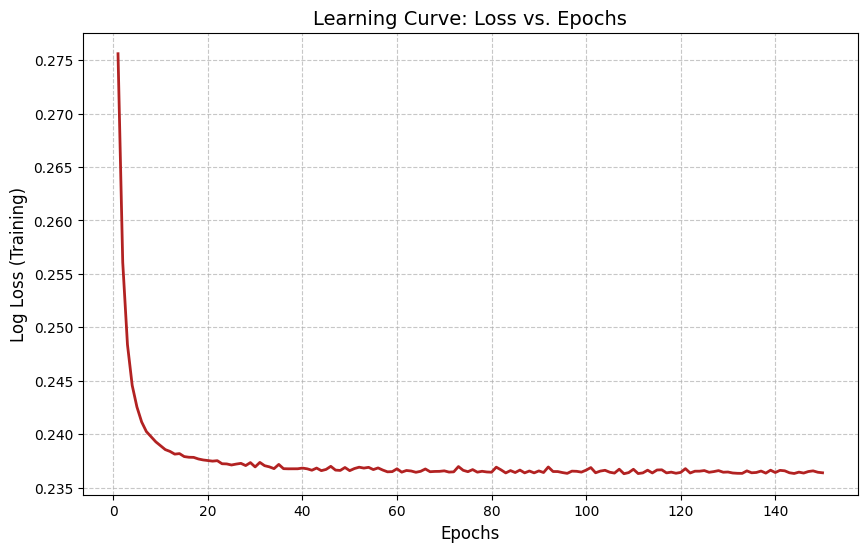

Final Loss at Epoch 300: 0.2364
Loss at Epoch 130: 0.2365


In [10]:
# Check learning curve
plt.figure(figsize=(10, 6))
plt.plot(
    range(1, len(pilot_model.loss_history_) + 1),
    pilot_model.loss_history_,
    color="firebrick",
    linewidth=2,
)

plt.title("Learning Curve: Loss vs. Epochs", fontsize=14)
plt.xlabel("Epochs", fontsize=12)
plt.ylabel("Log Loss (Training)", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.7)
plt.show()

print(f"Final Loss at Epoch 300: {pilot_model.loss_history_[-1]:.4f}")
print(f"Loss at Epoch 130: {pilot_model.loss_history_[129]:.4f}")

In [11]:
# Perform hyperparameter tuning
# Instantiate pipeline with SGDWrapper
pipeline = Pipeline([("scaler", StandardScaler()), ("logreg", MinibatchSGDWrapper())])

# Define hyperparameter ranges
param_dist = {
    "logreg__eta0": loguniform(1e-4, 1e-1),
    # 
    "logreg__batch_size": [32, 64, 128],
    # Set best epochs
    "logreg__epochs": [50],
}

# RandomizedSearchCV is more robust than manual iterations as the former runs jobs in parallel
random_search = RandomizedSearchCV(
    pipeline,
    param_distributions=param_dist,
    n_iter=50,
    cv=5,
    scoring="accuracy",
    n_jobs=-1,
    random_state=42,
    verbose=1,
)

In [12]:
# Tune hyperparameter via random_search
random_search.fit(X_train, y_train)

Fitting 5 folds for each of 50 candidates, totalling 250 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...GDWrapper())])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'logreg__batch_size': [32, 64, ...], 'logreg__epochs': [50], 'logreg__eta0': <scipy.stats....001D3279FBC50>}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",50
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0

In [13]:
# Log best model
best_model = random_search.best_estimator_

print(f"Best Params: {random_search.best_params_}")
print(f"Best CV Accuracy: {random_search.best_score_:.4f}")

Best Params: {'logreg__batch_size': 64, 'logreg__epochs': 50, 'logreg__eta0': 0.0018856783874794994}
Best CV Accuracy: 0.8995


In [14]:
# Load results into a df
results_df = pd.DataFrame(random_search.cv_results_)
results_df["param_logreg__eta0"] = pd.to_numeric(results_df["param_logreg__eta0"])
results_df["param_logreg__epochs"] = pd.to_numeric(results_df["param_logreg__epochs"])
results_df["param_logreg__batch_size"] = pd.to_numeric(
    results_df["param_logreg__batch_size"]
)

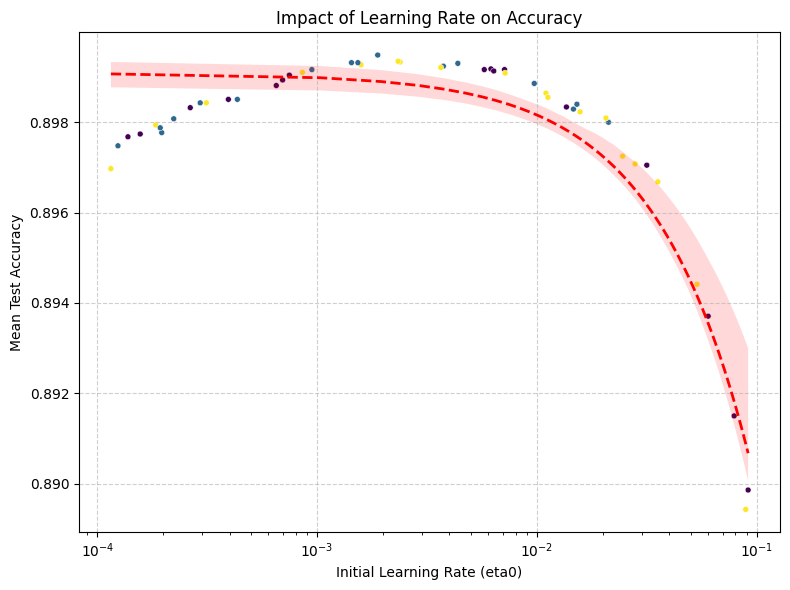

In [15]:
# Impact of adjusting the learning rate on accruacy
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=results_df,
    x="param_logreg__eta0",
    y="mean_test_score",
    hue="param_logreg__batch_size",
    palette="viridis",
    size=200,
    legend=False,
)
sns.regplot(
    data=results_df,
    x="param_logreg__eta0",
    y="mean_test_score",
    scatter=False,
    order=1,  # Uses polynomial regression instead of LOWESS
    color="red",
    line_kws={"linestyle": "--", "linewidth": 2},
)

plt.xscale("log")
plt.title("Impact of Learning Rate on Accuracy")
plt.xlabel("Initial Learning Rate (eta0)")
plt.ylabel("Mean Test Accuracy")
plt.grid(True, linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()

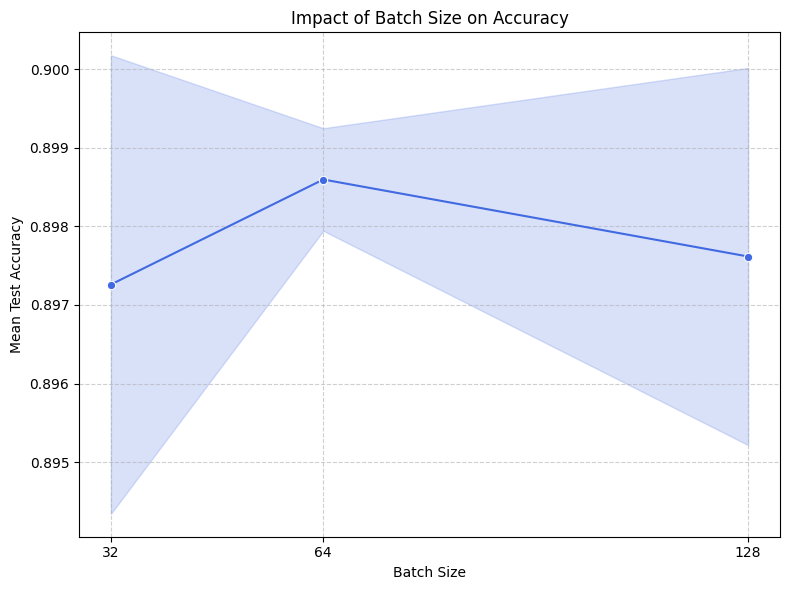

In [17]:
# Impact of batch size on accuracy
plt.figure(figsize=(8, 6))

sns.lineplot(
    data=results_df,
    x="param_logreg__batch_size",
    y="mean_test_score",
    marker="o",
    color="royalblue",
    errorbar="sd",  # Shows the standard deviation as a shaded band
)

# Forces the x-axis to only show your exact batch sizes
plt.xticks([32, 64, 128])
plt.title("Impact of Batch Size on Accuracy")
plt.xlabel("Batch Size")
plt.ylabel("Mean Test Accuracy")
plt.grid(True, linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()

In [18]:
# Test best model on test data
y_pred_test = best_model.predict(X_test)
test_accuracy = accuracy_score(y_test, y_pred_test)

print(f"Test Accuracy: {test_accuracy:.4f}")
print("\nClassification Report (Test Set):\n")
print(classification_report(y_test, y_pred_test))

Test Accuracy: 0.8950

Classification Report (Test Set):

              precision    recall  f1-score   support

           0       0.90      0.87      0.89      5353
           1       0.89      0.92      0.90      6151

    accuracy                           0.89     11504
   macro avg       0.90      0.89      0.89     11504
weighted avg       0.90      0.89      0.89     11504



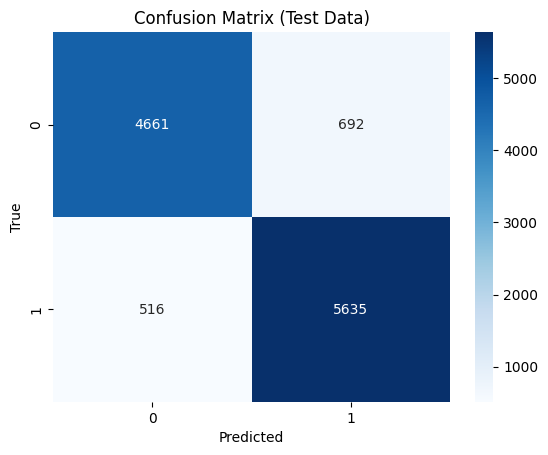

In [19]:
# Test data confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred_test)
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix (Test Data)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

In [20]:
# Predictions on test set
# SGDClassifier supports the `predict_proba` method for estimating probabilities
y_proba = best_model.predict_proba(X_test)

# Display head predictions with probabilities
print("Predicted Probabilities (First 5 Test Examples):\n")
for i, (prob_0, prob_1) in enumerate(y_proba[:5]):
    print(f"Example {i+1}: P(Loss)={prob_0:.4f}, P(Win)={prob_1:.4f}")

Predicted Probabilities (First 5 Test Examples):

Example 1: P(Loss)=0.9839, P(Win)=0.0161
Example 2: P(Loss)=0.0297, P(Win)=0.9703
Example 3: P(Loss)=0.0093, P(Win)=0.9907
Example 4: P(Loss)=0.4710, P(Win)=0.5290
Example 5: P(Loss)=0.4170, P(Win)=0.5830


In [21]:
# Feature impact
inner_model = best_model.named_steps["logreg"].model
feature_weights = inner_model.coef_[0]

# Map weights to feature names
feature_importances = pd.Series(data=feature_weights, index=X.columns).sort_values(
    ascending=False
)

print("Top 5 Positive Features (Increase P(Win)):\n")
print(feature_importances.head())

Top 5 Positive Features (Increase P(Win)):

attack_per_piece    3.096458
combo_mean          1.796626
apm                 0.950279
pps                 0.330118
glicko_rd           0.077784
dtype: float64


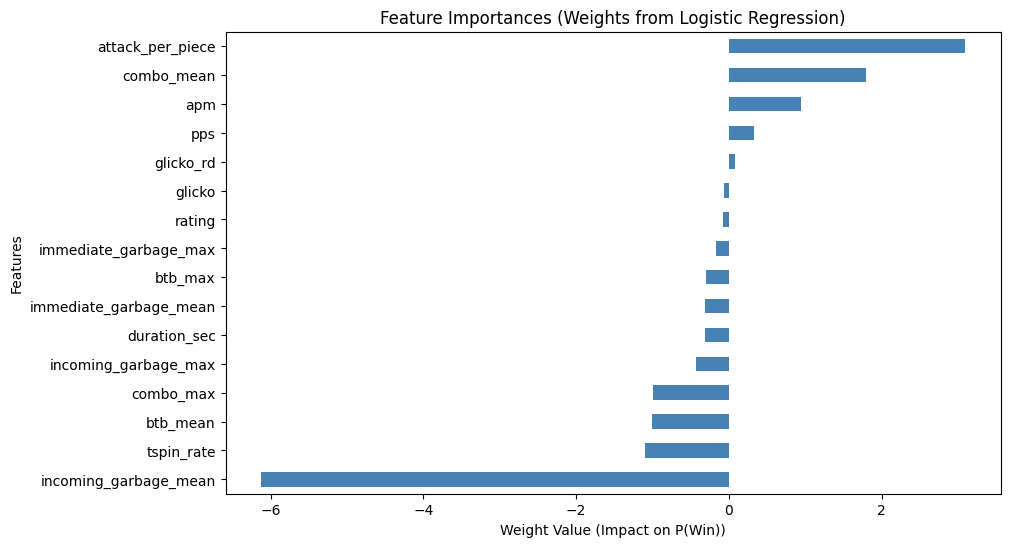

In [22]:
# Feature impact visualization
plt.figure(figsize=(10, 6))
feature_importances.sort_values().plot(kind="barh", color="steelblue")
plt.title("Feature Importances (Weights from Logistic Regression)")
plt.xlabel("Weight Value (Impact on P(Win))")
plt.ylabel("Features")
plt.show()